<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
# Clasificación de Sentimientos con BERT

In [1]:
!pip install datasets

Importamos AutoTokenizer, AutoModelForSequenceClassification y pipeline de Transformers

In [2]:
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

Cargamos el modelo preentrenado distilbert-base-uncased-finetuned-sst-2-english y su tokenizer

In [3]:
# Cargar el modelo preentrenado y el tokenizer
model_name = "distilbert-base-uncased-finetuned-sst-2-english"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Cargamos el dataset de IMDB para clasificar sentimientos

Usamos solo los 10 primeros textos

In [5]:
dataset = load_dataset("stanfordnlp/imdb")
texts = dataset['train']['text'][:10]

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Tokenizamos los textos

In [6]:
inputs = tokenizer(texts, padding=True, truncation=True, return_tensors="pt")

Realizamos predicciones

In [7]:
with torch.no_grad():
    outputs = model(**inputs)
    predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)

Obtenemos los resultados

In [8]:
labels = ['negative', 'positive']
for i, text in enumerate(texts):
    pred_label = labels[predictions[i].argmax()]
    confidence = predictions[i].max().item()
    print(f"Text: {text}")
    print(f"Prediction: {pred_label} (Confidence: {confidence:.4f})")
    print()

Text: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far betwee

Realizamos lo mismo usando pipeline de transformer

In [9]:
clasifier = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer, truncation=True)
pipeline_results = clasifier(texts)

Resultados del pipeline

In [10]:
for i, (text, result) in enumerate(zip(texts, pipeline_results)):
    print(f"Texto {i+1}: {text[:100]}...")
    print(f"Predicción: {result['label']} (Confianza: {result['score']:.4f})")

Texto 1: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it w...
Predicción: POSITIVE (Confianza: 0.7873)
Texto 2: "I Am Curious: Yellow" is a risible and pretentious steaming pile. It doesn't matter what one's poli...
Predicción: NEGATIVE (Confianza: 0.9992)
Texto 3: If only to avoid making this type of film in the future. This film is interesting as an experiment b...
Predicción: NEGATIVE (Confianza: 0.9982)
Texto 4: This film was probably inspired by Godard's Masculin, féminin and I urge you to see that film instea...
Predicción: POSITIVE (Confianza: 0.8145)
Texto 5: Oh, brother...after hearing about this ridiculous film for umpteen years all I can think of is that ...
Predicción: NEGATIVE (Confianza: 0.9994)
Texto 6: I would put this at the top of my list of films in the category of unwatchable trash! There are film...
Predicción: NEGATIVE (Confianza: 0.9990)
Texto 7: Whoever wrote the screenplay for this movie obviously never consult

# NER Tagging

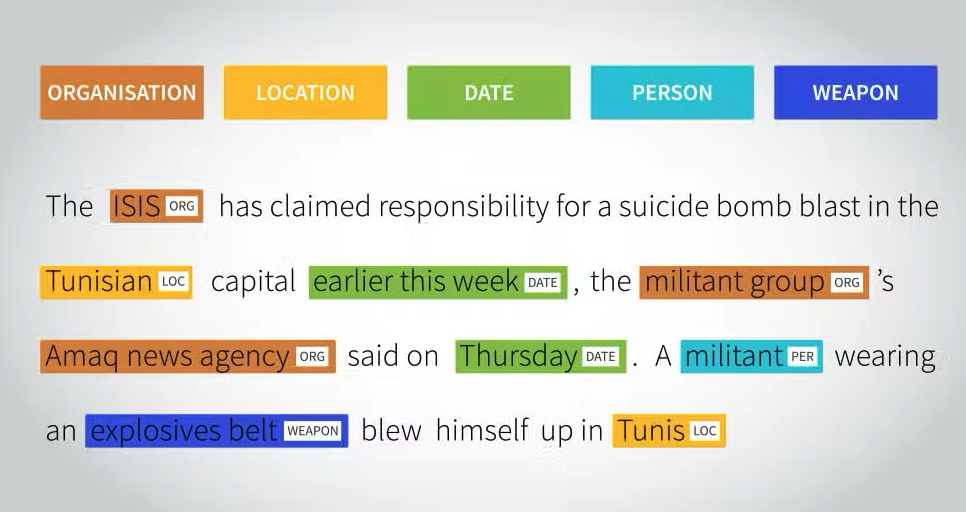

In [11]:
from transformers import AutoTokenizer, AutoModelForTokenClassification
from transformers import pipeline

Tokenizamos y definimos el modelo

In [12]:
tokenizer = AutoTokenizer.from_pretrained("dslim/bert-base-NER")
model = AutoModelForTokenClassification.from_pretrained("dslim/bert-base-NER")

config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Definimos la tarea que realizaremos

In [13]:
nlp = pipeline("ner", model=model, tokenizer=tokenizer)
example = "My name is Wolfgang Mozart and I live in Berlin"

Aplicamos en un ejemplo

In [14]:
ner_results = nlp(example)
print(ner_results)

[{'entity': 'B-PER', 'score': np.float32(0.9990833), 'index': 4, 'word': 'Wolfgang', 'start': 11, 'end': 19}, {'entity': 'I-PER', 'score': np.float32(0.9967392), 'index': 5, 'word': 'Mozart', 'start': 20, 'end': 26}, {'entity': 'B-LOC', 'score': np.float32(0.99963164), 'index': 10, 'word': 'Berlin', 'start': 41, 'end': 47}]


B-PER', 'score': np.float32(0.9990833), 'index': 4, 'word': 'Wolfgang', 'start': 11, 'end': 19}, {'entity': 'I-PER', 'score': np.float32(0.9967392), 'index': 5, 'word': 'Mozart', 'start': 20, 'end': 26}, {'entity': 'B-LOC', 'score': np.float32(0.99963164), 'index': 10, 'word': 'Berlin', 'start': 41, 'end': 47}]


